# Teil 3 - Modellierung

Notebook: `model.ipynb`  
Datensatz: `Steel_industry_data.csv`
        


In [1]:
import csv
from datetime import datetime

import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


def load_rows(path):
    rows = []
    with open(path, newline="", encoding="utf-8-sig") as file:
        reader = csv.DictReader(file, delimiter=";")
        for row in reader:
            timestamp = datetime.strptime(row["date"], "%d.%m.%Y %H:%M")
            rows.append(
                {
                    "Usage_kWh": float(row["Usage_kWh"]),
                    "Lagging_Current_Reactive.Power_kVarh": float(row["Lagging_Current_Reactive.Power_kVarh"]),
                    "Leading_Current_Reactive_Power_kVarh": float(row["Leading_Current_Reactive_Power_kVarh"]),
                    "Lagging_Current_Power_Factor": float(row["Lagging_Current_Power_Factor"]),
                    "Leading_Current_Power_Factor": float(row["Leading_Current_Power_Factor"]),
                    "NSM": int(row["NSM"]),
                    "WeekStatus": row["WeekStatus"],
                    "Day_of_week": row["Day_of_week"],
                    "Month": timestamp.month,
                    "Day": timestamp.day,
                    "Hour": timestamp.hour,
                }
            )
    return rows


rows = load_rows("Steel_industry_data.csv")
print(f"Anzahl Datensätze: {len(rows)}")
        


Anzahl Datensätze: 999


## Teilaufgabe 3.1
Ich teile den Datensatz in einen Trainingssatz und einen Testsatz auf. Da es sich um Messwerte in zeitlicher Reihenfolge handelt, verwende ich keinen zufälligen Split. Stattdessen trainiere ich auf den ersten 80 Prozent der Daten und teste auf den letzten 20 Prozent. So prüfe ich das Modell ehrlicher an späteren, für das Training noch unbekannten Zeitabschnitten.
        


In [2]:
X = [{key: value for key, value in row.items() if key != "Usage_kWh"} for row in rows]
y = [row["Usage_kWh"] for row in rows]

split_index = int(len(rows) * 0.8)
X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]

vectorizer = DictVectorizer(sparse=False)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Trainingsdaten: {len(X_train)}")
print(f"Testdaten: {len(X_test)}")
print(f"Anzahl Merkmale nach dem Encoding: {len(vectorizer.get_feature_names_out())}")
        


Trainingsdaten: 799
Testdaten: 200
Anzahl Merkmale nach dem Encoding: 17


## Teilaufgabe 3.2
Ich wähle eine `LinearRegression` aus `sklearn.linear_model`. Dieses Modell ist für ein erstes Regressionsprojekt gut geeignet, weil es einfach aufgebaut und leicht zu erklären ist. Es sagt einen numerischen Wert voraus und zeigt dadurch gut, was bereits funktioniert und wo Grenzen liegen. Zusätzlich verzichte ich bewusst auf `CO2(tCO2)` und `Load_Type`, weil diese Felder den Zielwert sehr direkt beschreiben und das Modell sonst künstlich stark wirken würde.
        


In [3]:
model = LinearRegression()
model.fit(X_train_vec, y_train)
test_predictions = model.predict(X_test_vec)

mae = mean_absolute_error(y_test, test_predictions)
r2 = r2_score(y_test, test_predictions)

print("Verwendetes sklearn-Modell: LinearRegression")
print(f"MAE auf den Testdaten: {mae:.4f} kWh")
print(f"R2 auf den Testdaten: {r2:.4f}")
        


Verwendetes sklearn-Modell: LinearRegression
MAE auf den Testdaten: 9.7114 kWh
R2 auf den Testdaten: 0.9412


## Teilaufgabe 3.3
Zur Plausibilitätsprüfung schaue ich mir einige Vorhersagen aus dem Testdatensatz an. Ich wähle bewusst Beispiele von tiefen, mittleren und hohen Verbräuchen, damit ich sehe, in welchen Bereichen die lineare Regression gut funktioniert und wo sie grössere Abweichungen hat.
        


In [4]:
paired_results = sorted(zip(y_test, test_predictions), key=lambda pair: pair[0])
selected_indices = [
    0,
    len(paired_results) // 4,
    len(paired_results) // 2,
    (3 * len(paired_results)) // 4,
    len(paired_results) - 1,
]

for index in selected_indices:
    actual, predicted = paired_results[index]
    difference = predicted - actual
    print(
        f"Echt: {actual:6.2f} kWh | Vorhersage: {predicted:6.2f} kWh | Differenz: {difference:+6.2f} kWh"
    )
        


Echt:   4.14 kWh | Vorhersage:   5.86 kWh | Differenz:  +1.72 kWh
Echt:   4.61 kWh | Vorhersage:   0.84 kWh | Differenz:  -3.77 kWh
Echt:   8.71 kWh | Vorhersage:   6.07 kWh | Differenz:  -2.64 kWh
Echt: 110.77 kWh | Vorhersage:  96.53 kWh | Differenz: -14.24 kWh
Echt: 143.21 kWh | Vorhersage: 144.77 kWh | Differenz:  +1.56 kWh


Die Vorhersagen sind insgesamt plausibel, aber klar nicht perfekt. Tiefe und mittlere Verbräuche werden meist ordentlich getroffen. Bei einzelnen Zeitpunkten liegt das Modell einige kWh daneben, und bei sehr hohen Lastspitzen unterschätzt es den echten Verbrauch teilweise deutlich. Das passt zu einer linearen Regression: Sie bildet grundlegende Zusammenhänge gut ab, kann abrupte oder komplexe Spitzen aber nicht vollständig erfassen. Gerade deshalb ist das Modell für einen ersten, ehrlichen Versuch gut geeignet.
        


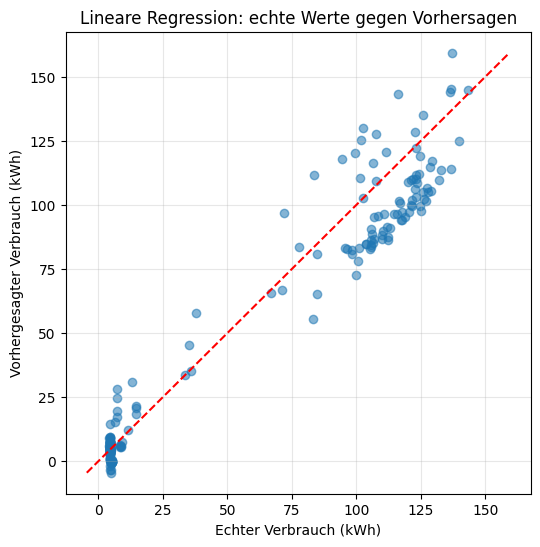

In [5]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_predictions, alpha=0.55)
diagonal_min = min(min(y_test), min(test_predictions))
diagonal_max = max(max(y_test), max(test_predictions))
plt.plot([diagonal_min, diagonal_max], [diagonal_min, diagonal_max], color="red", linestyle="--")
plt.xlabel("Echter Verbrauch (kWh)")
plt.ylabel("Vorhergesagter Verbrauch (kWh)")
plt.title("Lineare Regression: echte Werte gegen Vorhersagen")
plt.grid(alpha=0.3)
plt.show()
        


## Teilaufgabe 3.4
Die Adresse des Repository ist unverändert. Deshalb ist an dieser Stelle keine weitere Aktion nötig.
        
